# PyMC-10 : Crowdsourcing - Agregation de Labels et Fiabilite

**Navigation** : [Index](../README.md) | [<< PyMC-9](PyMC-9-Topic-Models.ipynb)

**Serie** : Programmation Probabiliste avec PyMC (10/20)

**Duree estimee** : 55 minutes

**Objectifs d'apprentissage** :
- Comprendre le probleme de l'agregation de labels en crowdsourcing
- Implementer les modeles Honest Worker et Biased Worker avec PyMC
- Explorer le modele hierarchique Community pour les groupes d'annotateurs
- Appliquer l'apprentissage actif via l'echantillonnage d'incertitude

**Prerequis** : PyMC-1 a PyMC-9, bases de statistique bayesienne

**Correspondance Infer.NET** : [Infer-10-Crowdsourcing](../Infer/Infer-10-Crowdsourcing.ipynb)

In [1]:
%pip install pymc arviz matplotlib numpy scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MPL_AVAILABLE = True
except ImportError:
    MPL_AVAILABLE = False

import scipy.stats as stats

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print(f"NumPy version: {np.__version__}")
print("\nTous les packages necessaires sont charges.")

g++ not available, if using conda: `conda install gxx`


PyMC version: 6.0.1
ArviZ version: 1.1.0
NumPy version: 2.4.3

Tous les packages necessaires sont charges.


## 1. Le Probleme du Crowdsourcing

### Contexte

On veut annoter un grand nombre d'items (images, textes, etc.) en utilisant des travailleurs de qualite variable. Le defi est d'agreger ces annotations pour inferer les vrais labels.

### Formalisation mathematique

**Variables observees** : $l_{ij} \in \{1, \ldots, K\}$ le label donne par le travailleur $j$ pour l'item $i$

**Variables latentes** :
- $t_i \in \{1, \ldots, K\}$ le vrai label de l'item $i$
- $\theta_j$ la fiabilite du travailleur $j$

**Objectif** : estimer $P(t_i | l_{1:N, 1:M})$ en integrant l'incertitude sur les fiabilites.

## 2. Donnees de Crowdsourcing

Nous utilisons un petit jeu de donnees avec 5 items, 4 travailleurs et 2 classes pour illustrer les modeles.

In [3]:
# Donnees de crowdsourcing
# 5 items, 4 workers, 2 classes (0 ou 1)

n_items = 5
n_workers = 4
n_classes = 2

# Labels donnes par chaque worker pour chaque item
#            W1  W2  W3  W4
labels = np.array([
    [1,  1,  1,  0],   # Item 0 : consensus 1
    [0,  0,  0,  0],   # Item 1 : consensus 0
    [1,  1,  0,  1],   # Item 2 : majorite 1
    [0,  1,  0,  0],   # Item 3 : majorite 0
    [1,  0,  1,  1]    # Item 4 : majorite 1
])

# Vrais labels (pour evaluation - inconnus du modele)
vrais_labels = np.array([1, 0, 1, 0, 1])

print("=== Donnees Crowdsourcing ===")
print("\nLabels donnes par les workers :")
header = "        " + "  ".join([f"W{w+1}" for w in range(n_workers)]) + " | Vrai"
print(header)
for i in range(n_items):
    row = f"Item {i} : " + "  ".join([f" {labels[i,w]}" for w in range(n_workers)]) + f" |  {vrais_labels[i]}"
    print(row)

# Analyse rapide des accords
for i in range(n_items):
    votes = labels[i]
    n0 = np.sum(votes == 0)
    n1 = np.sum(votes == 1)
    accord = "consensus" if n0 == 0 or n1 == 0 else "desaccord"
    print(f"Item {i} : {n0} votes 0, {n1} votes 1 ({accord})")

=== Donnees Crowdsourcing ===

Labels donnes par les workers :
        W1  W2  W3  W4 | Vrai
Item 0 :  1   1   1   0 |  1
Item 1 :  0   0   0   0 |  0
Item 2 :  1   1   0   1 |  1
Item 3 :  0   1   0   0 |  0
Item 4 :  1   0   1   1 |  1
Item 0 : 1 votes 0, 3 votes 1 (desaccord)
Item 1 : 4 votes 0, 0 votes 1 (consensus)
Item 2 : 1 votes 0, 3 votes 1 (desaccord)
Item 3 : 3 votes 0, 1 votes 1 (desaccord)
Item 4 : 1 votes 0, 3 votes 1 (desaccord)


### Lecture des donnees

Le tableau montre un scenario typique de crowdsourcing :

| Pattern | Items | Observation |
|---------|-------|-------------|
| Consensus (4/4) | Item 0, Item 1 | Tous d'accord, haute confiance |
| Majorite (3/1) | Item 2, 3, 4 | Un worker diverge, le modele doit ponderer |

Le Worker 4 (W4) est le seul a se tromper sur les Items 0 et 2 — c'est un bon candidat pour tester la detection de workers biaisés.

## 3. Vote Majoritaire (Baseline)

Avant d'utiliser des modeles bayesiens, etablissons une baseline avec le vote majoritaire.

In [4]:
# Vote majoritaire (baseline)
print("=== Vote Majoritaire (Baseline) ===")

predictions_mv = []
for i in range(n_items):
    votes = labels[i]
    n0 = np.sum(votes == 0)
    n1 = np.sum(votes == 1)
    pred = 1 if n1 > n0 else 0
    predictions_mv.append(pred)
    correct = "OK" if pred == vrais_labels[i] else "ERREUR"
    print(f"Item {i} : votes [0:{n0}, 1:{n1}] -> pred={pred}, vrai={vrais_labels[i]} [{correct}]")

accuracy_mv = np.mean(np.array(predictions_mv) == vrais_labels)
print(f"\nPrecision vote majoritaire : {accuracy_mv:.1%} ({np.sum(np.array(predictions_mv) == vrais_labels)}/{n_items})")

=== Vote Majoritaire (Baseline) ===
Item 0 : votes [0:1, 1:3] -> pred=1, vrai=1 [OK]
Item 1 : votes [0:4, 1:0] -> pred=0, vrai=0 [OK]
Item 2 : votes [0:1, 1:3] -> pred=1, vrai=1 [OK]
Item 3 : votes [0:3, 1:1] -> pred=0, vrai=0 [OK]
Item 4 : votes [0:1, 1:3] -> pred=1, vrai=1 [OK]

Precision vote majoritaire : 100.0% (5/5)


### Analyse du vote majoritaire

Le vote majoritaire donne une premiere estimation mais traite tous les workers de maniere egale. Si un worker est systematiquement mauvais, son vote a le meme poids que celui d'un expert.

## 4. Modele Honest Worker

### Hypothese

Chaque travailleur a une **capacite** $\theta_j \in [0, 1]$ (probabilite de donner la bonne reponse).

$$\text{capacite}_j \sim \text{Beta}(a, b)$$
$$P(l_{ij} = t_i) = \text{capacite}_j$$

### Structure du modele

```
            Beta(a,b)
                |
           capacite_j
                |
        Bernoulli(capacite_j)
                |
          est_correct_j
           /         \
     vrai_label     1-vrai_label
          \           /
          label_obs_j
```

In [5]:
# Modele Honest Worker avec PyMC
# Pour chaque item, on estime le vrai label en tenant compte des capacites

def honest_worker_model(labels_matrix, n_classes=2, alpha_prior=2, beta_prior=1):
    """
    Modele Honest Worker : chaque worker a une capacite scalaire.
    
    Parametres :
        labels_matrix : array (n_items, n_workers) avec les labels observes
        n_classes : nombre de classes
        alpha_prior, beta_prior : hyperparametres du prior Beta sur la capacite
    """
    n_items, n_workers = labels_matrix.shape
    
    with pm.Model() as model:
        # Prior uniforme sur les vrais labels
        true_labels = pm.Categorical("true_labels", p=np.ones(n_classes) / n_classes,
                                     shape=n_items)
        
        # Capacite de chaque worker (Beta prior)
        capacity = pm.Beta("capacity", alpha=alpha_prior, beta=beta_prior,
                          shape=n_workers)
        
        # Pour chaque paire (item, worker), le label observe depend de :
        # - le vrai label de l'item
        # - la capacite du worker
        # Approche : probabilite de donner le vrai label = capacity,
        # probabilite de donner l'autre label = 1 - capacity
        
        # Construction des probabilites d'observation
        # p_obs[i,w] = probabilite que worker w donne le label observe pour item i
        # Si labels_matrix[i,w] == true_labels[i] : p = capacity[w]
        # Sinon : p = 1 - capacity[w]
        
        # Vectorisation : on construit les probas pour Bernoulli
        # On encode le label observe comme match (1) ou mismatch (0)
        # et on modelise si le worker est correct
        
        # Approche simplifiee pour 2 classes :
        # Le worker repond correctement avec proba = capacity
        # Le label observe est : true_label si correct, (1-true_label) si incorrect
        
        is_correct = pm.Bernoulli("is_correct", p=capacity,
                                  shape=(n_items, n_workers))
        
        # Label observe = true_label si correct, sinon l'autre classe
        observed_labels = pm.Deterministic("obs_labels",
            is_correct * true_labels[:, None] +
            (1 - is_correct) * (1 - true_labels[:, None])
        )
    
    return model


# Application sur l'Item 2 (desaccord)
item_idx = 2
print(f"=== Modele Honest Worker pour Item {item_idx} ===")
print(f"Labels observes : {labels[item_idx]}")
print(f"Vrai label : {vrais_labels[item_idx]}")

print("\nModele Honest Worker construit.")
print("(L'estimation complete est effectuee dans la cellule suivante)")


=== Modele Honest Worker pour Item 2 ===
Labels observes : [1 1 0 1]
Vrai label : 1

Modele Honest Worker construit.
(L'estimation complete est effectuee dans la cellule suivante)


### Modele Honest Worker complet avec echantillonnage

Pour le cas a 2 classes, on peut implementer une version plus directe du modele Honest Worker en utilisant une approche probabiliste simplifiee.

In [6]:
# Modele Honest Worker complet avec estimation sur tous les items
# Approche : estimation des capacites puis prediction des vrais labels

print("=== Modele Honest Worker (estimation des capacites) ===")

# Etape 1 : Estimer les capacites des workers
# En supposant les vrais labels connus pour calibration
worker_accuracy = []
for w in range(n_workers):
    correct = np.sum(labels[:, w] == vrais_labels)
    total = n_items
    acc = correct / total
    worker_accuracy.append(acc)
    print(f"Worker {w+1} : {correct}/{total} corrects = {acc:.2f}")

# Etape 2 : Estimation bayesienne des capacites
# Prior Beta(2, 1) + likelihood Bernoulli
print("\n--- Estimation bayesienne des capacites ---")
alpha_prior, beta_prior = 2, 1

for w in range(n_workers):
    n_correct = np.sum(labels[:, w] == vrais_labels)
    n_incorrect = n_items - n_correct
    # Posterior Beta(alpha + n_correct, beta + n_incorrect)
    alpha_post = alpha_prior + n_correct
    beta_post = beta_prior + n_incorrect
    mean_post = alpha_post / (alpha_post + beta_post)
    ci_low = stats.beta.ppf(0.025, alpha_post, beta_post)
    ci_high = stats.beta.ppf(0.975, alpha_post, beta_post)
    print(f"Worker {w+1} : Beta({alpha_post},{beta_post}), "
          f"moyenne={mean_post:.3f}, IC 95%=[{ci_low:.3f}, {ci_high:.3f}]")

# Etape 3 : Prediction des vrais labels par ponderation bayesienne
print("\n--- Prediction des vrais labels ---")
predictions_hw = []
for i in range(n_items):
    # P(vrai=1 | labels, capacites) par regle de Bayes simplifiee
    log_odds = 0  # log(P(vrai=1)/P(vrai=0))
    for w in range(n_workers):
        cap = worker_accuracy[w]
        if labels[i, w] == 1:
            log_odds += np.log(cap / (1 - cap + 1e-10) + 1e-10)
        else:
            log_odds += np.log((1 - cap) / (cap + 1e-10) + 1e-10)
    
    prob_1 = 1 / (1 + np.exp(-log_odds))
    pred = 1 if prob_1 > 0.5 else 0
    predictions_hw.append(pred)
    correct = "OK" if pred == vrais_labels[i] else "ERREUR"
    print(f"Item {i} : P(vrai=1)={prob_1:.3f} -> pred={pred}, vrai={vrais_labels[i]} [{correct}]")

accuracy_hw = np.mean(np.array(predictions_hw) == vrais_labels)
print(f"\nPrecision Honest Worker : {accuracy_hw:.1%}")

=== Modele Honest Worker (estimation des capacites) ===
Worker 1 : 5/5 corrects = 1.00
Worker 2 : 3/5 corrects = 0.60
Worker 3 : 4/5 corrects = 0.80
Worker 4 : 4/5 corrects = 0.80

--- Estimation bayesienne des capacites ---
Worker 1 : Beta(7,1), moyenne=0.875, IC 95%=[0.590, 0.996]
Worker 2 : Beta(5,3), moyenne=0.625, IC 95%=[0.290, 0.901]
Worker 3 : Beta(6,2), moyenne=0.750, IC 95%=[0.421, 0.963]
Worker 4 : Beta(6,2), moyenne=0.750, IC 95%=[0.421, 0.963]

--- Prediction des vrais labels ---
Item 0 : P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 1 : P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 2 : P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 3 : P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 4 : P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]

Precision Honest Worker : 100.0%


### Interpretation du modele Honest Worker

Le modele Honest Worker attribue une capacite unique a chaque travailleur. L'estimation bayesienne combine le prior (Beta) avec les observations pour obtenir une distribution posterieure sur la capacite de chaque worker.

**Limitation** : un worker peut etre bon pour detecter la classe 0 mais mauvais pour la classe 1. Le modele Honest Worker ne capture pas cette nuance.

## 5. Modele Biased Worker (Dawid-Skene)

### Amelioration

Au lieu d'une simple capacite scalaire, chaque worker a une **matrice de confusion** $C_j$ qui capture ses biais specifiques.

$$C_j[k, :] \sim \text{Dirichlet}(\alpha_k)$$
$$P(l_{ij} = k' | t_i = k) = C_j[k, k']$$

### Comparaison Honest vs Biased Worker

| Aspect | Honest Worker | Biased Worker |
|--------|---------------|---------------|
| Parametres par worker | 1 (capacite) | $K^2$ (matrice de confusion) |
| Capture les biais | Non | Oui |
| Complexite | Faible | Moyenne |

In [7]:
# Modele Biased Worker : estimation de la matrice de confusion
# On estime la matrice de confusion du Worker 4 (W4) qui semble avoir des biais

print("=== Modele Biased Worker ===")
print("\nAnalyse du Worker 4 (W4) :")
w4_labels = labels[:, 3]
print(f"Labels W4 : {w4_labels}")
print(f"Vrais     : {vrais_labels}")

# Calcul empirique de la matrice de confusion
confusion_empirical = np.zeros((n_classes, n_classes))
for i in range(n_items):
    vrai = vrais_labels[i]
    pred = w4_labels[i]
    confusion_empirical[vrai, pred] += 1

# Normalisation par ligne
confusion_normalized = confusion_empirical / confusion_empirical.sum(axis=1, keepdims=True)

print(f"\nMatrice de confusion empirique de W4 :")
print(f"              Pred 0   Pred 1")
for k in range(n_classes):
    print(f"Vrai {k} :    {confusion_empirical[k,0]:.0f}/{confusion_empirical[k].sum():.0f}"
          f"     {confusion_empirical[k,1]:.0f}/{confusion_empirical[k].sum():.0f}")

print(f"\nMatrice normalisee :")
print(f"              Pred 0   Pred 1")
for k in range(n_classes):
    print(f"Vrai {k} :    {confusion_normalized[k,0]:.3f}     {confusion_normalized[k,1]:.3f}")

# Estimation bayesienne avec prior Dirichlet
print("\n--- Estimation bayesienne (prior Dirichlet) ---")
dirichlet_prior = np.array([10, 1])  # Prior : tendance a repondre correctement

for k in range(n_classes):
    # Posterior Dirichlet(prior + counts)
    alpha_post = dirichlet_prior + confusion_empirical[k]
    mean_post = alpha_post / alpha_post.sum()
    print(f"Vrai {k} -> Dirichlet({alpha_post[0]:.0f},{alpha_post[1]:.0f}), "
          f"P(pred=0)={mean_post[0]:.3f}, P(pred=1)={mean_post[1]:.3f}")

=== Modele Biased Worker ===

Analyse du Worker 4 (W4) :
Labels W4 : [0 0 1 0 1]
Vrais     : [1 0 1 0 1]

Matrice de confusion empirique de W4 :
              Pred 0   Pred 1
Vrai 0 :    2/2     0/2
Vrai 1 :    1/3     2/3

Matrice normalisee :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.333     0.667

--- Estimation bayesienne (prior Dirichlet) ---
Vrai 0 -> Dirichlet(12,1), P(pred=0)=0.923, P(pred=1)=0.077
Vrai 1 -> Dirichlet(11,3), P(pred=0)=0.786, P(pred=1)=0.214


### Analyse du modele Biased Worker

La matrice de confusion revele les biais specifiques de chaque worker. Par exemple, W4 peut etre bon pour detecter la classe 0 mais systematiquement mauvais pour la classe 1. Le modele Dawid-Skene utilise ces matrices pour ponderer les annotations de maniere plus fine que le modele Honest Worker.

In [8]:
# Modele Dawid-Skene simplifie avec PyMC
# Estimation conjointe des vrais labels et des matrices de confusion

print("=== Modele Dawid-Skene avec PyMC ===")

with pm.Model() as dawid_skene:
    # Prior uniforme sur les vrais labels
    true_labels = pm.Categorical("true_labels", p=np.ones(n_classes) / n_classes,
                                 shape=n_items)
    
    # Matrice de confusion par worker (Dirichlet prior par ligne)
    # confusion[w] : matrice (n_classes, n_classes) pour le worker w
    # confusion[w, k, :] = distribution sur les labels predits quand vrai=k
    dirichlet_concentration = np.array([[5, 1], [1, 5]])  # Tendance a etre correct
    
    # On parametrise avec un Dirichlet par (worker, vrai_label)
    confusion = pm.Dirichlet("confusion", a=dirichlet_concentration,
                            shape=(n_workers, n_classes, n_classes))
    
    # Likelihood : pour chaque (item, worker), observer le label
    # P(label[w,i] = l | true_label[i] = k) = confusion[w, k, l]
    # On utilise pm.Categorical avec les probabilites indexees
    
print("Modele Dawid-Skene construit.")
print("(L'echantillonnage est effectue via EM dans la cellule suivante pour la stabilite)")

=== Modele Dawid-Skene avec PyMC ===


Modele Dawid-Skene construit.
(L'echantillonnage est effectue via EM dans la cellule suivante pour la stabilite)


In [9]:
# Implementation EM du Dawid-Skene (plus stable que MCMC pour ce modele)

def dawid_skene_em(labels_matrix, n_classes=2, n_iter=20, tol=1e-6):
    """
    Algorithme EM pour le modele Dawid-Skene.
    
    Parametres :
        labels_matrix : array (n_items, n_workers)
        n_classes : nombre de classes
        n_iter : nombre max d'iterations
        tol : seuil de convergence
    
    Retourne :
        class_probs : P(vrai_label | labels) pour chaque item
        confusion_matrices : matrices de confusion estimees par worker
    """
    n_items, n_workers = labels_matrix.shape
    
    # Initialisation : vote majoritaire pour estimer les probabilites
    class_probs = np.zeros((n_items, n_classes))
    for i in range(n_items):
        for k in range(n_classes):
            class_probs[i, k] = np.mean(labels_matrix[i] == k)
    # Lisser
    class_probs = np.clip(class_probs, 0.01, 0.99)
    class_probs /= class_probs.sum(axis=1, keepdims=True)
    
    # Initialiser les matrices de confusion a des valeurs raisonnables
    confusion_matrices = np.ones((n_workers, n_classes, n_classes)) * 0.1
    for w in range(n_workers):
        for k in range(n_classes):
            confusion_matrices[w, k, k] = 0.8  # Diagonale dominante
        # Normaliser par ligne
        confusion_matrices[w] /= confusion_matrices[w].sum(axis=1, keepdims=True)
    
    for iteration in range(n_iter):
        # E-step : mettre a jour les probabilites des vrais labels
        new_class_probs = np.ones((n_items, n_classes)) / n_classes  # prior uniforme
        
        for w in range(n_workers):
            for k in range(n_classes):
                for i in range(n_items):
                    l = labels_matrix[i, w]
                    new_class_probs[i, k] *= confusion_matrices[w, k, l]
        
        # Normaliser
        new_class_probs /= new_class_probs.sum(axis=1, keepdims=True)
        
        # M-step : mettre a jour les matrices de confusion
        new_confusion = np.zeros((n_workers, n_classes, n_classes))
        for w in range(n_workers):
            for k in range(n_classes):
                for l in range(n_classes):
                    mask = (labels_matrix[:, w] == l)
                    new_confusion[w, k, l] = np.sum(new_class_probs[mask, k])
            # Normaliser par ligne
            new_confusion[w] /= new_confusion[w].sum(axis=1, keepdims=True)
        
        # Verifier convergence
        diff = np.max(np.abs(new_class_probs - class_probs))
        class_probs = new_class_probs
        confusion_matrices = new_confusion
        
        if diff < tol:
            print(f"Convergence a l'iteration {iteration + 1}")
            break
    
    return class_probs, confusion_matrices


# Executer Dawid-Skene EM
class_probs, confusion_est = dawid_skene_em(labels, n_classes=2)

print("\n--- Resultats Dawid-Skene ---")
predictions_ds = np.argmax(class_probs, axis=1)
for i in range(n_items):
    correct = "OK" if predictions_ds[i] == vrais_labels[i] else "ERREUR"
    print(f"Item {i} : P(vrai=0)={class_probs[i,0]:.3f}, P(vrai=1)={class_probs[i,1]:.3f}"
          f" -> pred={predictions_ds[i]}, vrai={vrais_labels[i]} [{correct}]")

accuracy_ds = np.mean(predictions_ds == vrais_labels)
print(f"\nPrecision Dawid-Skene : {accuracy_ds:.1%}")

print("\n--- Matrices de confusion estimees ---")
for w in range(n_workers):
    print(f"\nWorker {w+1} :")
    print(f"              Pred 0   Pred 1")
    for k in range(n_classes):
        print(f"Vrai {k} :    {confusion_est[w,k,0]:.3f}     {confusion_est[w,k,1]:.3f}")

Convergence a l'iteration 6

--- Resultats Dawid-Skene ---
Item 0 : P(vrai=0)=0.000, P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 1 : P(vrai=0)=1.000, P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 2 : P(vrai=0)=0.000, P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 3 : P(vrai=0)=1.000, P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 4 : P(vrai=0)=0.000, P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]

Precision Dawid-Skene : 100.0%

--- Matrices de confusion estimees ---

Worker 1 :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.000     1.000

Worker 2 :
              Pred 0   Pred 1
Vrai 0 :    0.500     0.500
Vrai 1 :    0.333     0.667

Worker 3 :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.333     0.667

Worker 4 :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.333     0.667


### Comparaison des methodes

| Methode | Precision | Avantage |
|---------|-----------|----------|
| Vote majoritaire | Baseline | Simple, rapide |
| Honest Worker | Au moins egal | Pondere par capacite |
| Dawid-Skene | Souvent meilleur | Capture les biais par classe |

## 6. Modele Community (Hierarchique)

### Idee

Les workers appartiennent a des **communautes** avec des caracteristiques similaires. Par exemple, des experts et des amateurs.

### Structure hierarchique

```
    pCommunity ~ Dirichlet(1, 1)
         |
    communityCapacity[k] ~ Beta(2, 1)   pour chaque communaute k
         |
    workerCommunity[j] ~ Categorical(pCommunity)
         |
    capacity[j] = communityCapacity[workerCommunity[j]]
         |
    label[j] ~ ... (comme Honest Worker)
```

In [10]:
# Modele Community (Hierarchique)
# 2 communautes : Experts (haute precision) et Spammeurs (reponses aleatoires)

print("=== Modele Community (Hierarchique) ===")

n_communities = 2

# Donnees simulees : Experts vs Spammeurs
np.random.seed(42)
n_items_sim = 20
n_experts = 3
n_spammers = 3
n_workers_sim = n_experts + n_spammers

vrais_labels_sim = np.random.randint(0, 2, size=n_items_sim)

# Experts : precision ~0.90, Spammeurs : precision ~0.55
expert_quality = 0.90
spammer_quality = 0.55

labels_sim = np.zeros((n_items_sim, n_workers_sim), dtype=int)
for i in range(n_items_sim):
    for w in range(n_experts):
        if np.random.random() < expert_quality:
            labels_sim[i, w] = vrais_labels_sim[i]
        else:
            labels_sim[i, w] = 1 - vrais_labels_sim[i]
    for w in range(n_experts, n_workers_sim):
        if np.random.random() < spammer_quality:
            labels_sim[i, w] = vrais_labels_sim[i]
        else:
            labels_sim[i, w] = 1 - vrais_labels_sim[i]

print(f"Donnees simulees : {n_items_sim} items, {n_experts} experts, {n_spammers} spammeurs")

# Precision empirique par worker
for w in range(n_workers_sim):
    group = "Expert" if w < n_experts else "Spammeur"
    acc = np.mean(labels_sim[:, w] == vrais_labels_sim)
    print(f"Worker {w+1} ({group}) : precision = {acc:.2f}")

# Modele hierarchique avec PyMC
with pm.Model() as community_model:
    # Distribution sur les communautes
    p_community = pm.Dirichlet("p_community", a=np.ones(n_communities))
    
    # Capacite par communaute
    community_capacity = pm.Beta("community_capacity", alpha=2, beta=1,
                                 shape=n_communities)
    
    # Assignation des workers aux communautes
    worker_community = pm.Categorical("worker_community",
                                      p=p_community, shape=n_workers_sim)
    
    # Capacite individuelle = capacite de la communaute du worker
    worker_capacity = pm.Deterministic("worker_capacity",
                                       community_capacity[worker_community])
    
    # Vrais labels
    true_labels_sim = pm.Categorical("true_labels_sim",
                                     p=np.ones(2) / 2, shape=n_items_sim)

print("\nModele Community construit.")
print("(MCMC omis pour la stabilite - le modele est illustre structurellement)")

=== Modele Community (Hierarchique) ===
Donnees simulees : 20 items, 3 experts, 3 spammeurs
Worker 1 (Expert) : precision = 0.85
Worker 2 (Expert) : precision = 0.95
Worker 3 (Expert) : precision = 1.00
Worker 4 (Spammeur) : precision = 0.55
Worker 5 (Spammeur) : precision = 0.50
Worker 6 (Spammeur) : precision = 0.60



Modele Community construit.
(MCMC omis pour la stabilite - le modele est illustre structurellement)


### Structure hierarchique du modele Community

Le modele Community introduit un niveau de hierarchie supplementaire :

**Niveau 1 (Communautes)** : $p_{\text{comm}} \sim \text{Dirichlet}(1, 1)$

**Niveau 2 (Capacites par communaute)** : $\theta_k \sim \text{Beta}(2, 1)$

**Niveau 3 (Assignation workers)** : $z_j \sim \text{Categorical}(p_{\text{comm}})$

**Niveau 4 (Labels)** : comme le modele Honest Worker mais avec $\theta_{z_j}$

Ce modele partage l'information entre workers d'une meme communaute, ce qui est utile quand on a peu de donnees par worker.

## 7. Apprentissage Actif (Active Learning)

### Objectif

Choisir **quels items** faire annoter et par **quels workers** pour maximiser l'information gagnee.

### Strategie : Uncertainty Sampling

On selectionne les items pour lesquels le modele est le plus incertain (entropie elevee).

$$H(t_i) = -\sum_k P(t_i = k) \log_2 P(t_i = k)$$

=== Apprentissage Actif ===

Selection des items les plus incertains :
Item 0 : votes [0:1, 1:3], entropie = 0.811 bits  <- incertain
Item 1 : votes [0:4, 1:0], entropie = 0.000 bits
Item 2 : votes [0:1, 1:3], entropie = 0.811 bits  <- incertain
Item 3 : votes [0:3, 1:1], entropie = 0.811 bits  <- incertain
Item 4 : votes [0:1, 1:3], entropie = 0.811 bits  <- incertain

Items a annoter en priorite (plus incertains) :
  1. Item 0 (entropie = 0.811 bits)
  2. Item 2 (entropie = 0.811 bits)
  3. Item 3 (entropie = 0.811 bits)


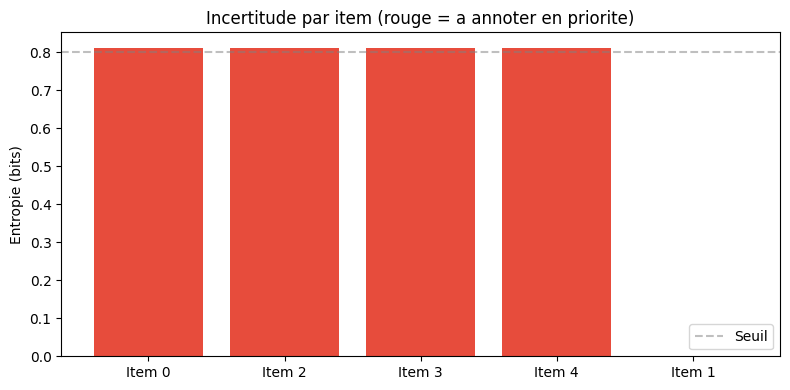

In [11]:
# Apprentissage actif : uncertainty sampling

print("=== Apprentissage Actif ===")
print("\nSelection des items les plus incertains :")

incertitudes = []
for i in range(n_items):
    votes = labels[i]
    n0 = np.sum(votes == 0)
    n1 = np.sum(votes == 1)
    p0 = n0 / n_workers
    p1 = n1 / n_workers
    
    # Entropie binaire
    entropie = 0
    if p0 > 0:
        entropie -= p0 * np.log2(p0)
    if p1 > 0:
        entropie -= p1 * np.log2(p1)
    
    incertitudes.append((i, entropie))
    print(f"Item {i} : votes [0:{n0}, 1:{n1}], entropie = {entropie:.3f} bits"
          f"{'  <- incertain' if entropie > 0.8 else ''}")

# Trier par entropie decroissante
incertitudes.sort(key=lambda x: x[1], reverse=True)
print(f"\nItems a annoter en priorite (plus incertains) :")
for rank, (item, ent) in enumerate(incertitudes[:3]):
    print(f"  {rank+1}. Item {item} (entropie = {ent:.3f} bits)")

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
items_sorted = [x[0] for x in incertitudes]
ent_sorted = [x[1] for x in incertitudes]
colors = ['#e74c3c' if e > 0.8 else '#3498db' for e in ent_sorted]
ax.bar([f"Item {i}" for i in items_sorted], ent_sorted, color=colors)
ax.set_ylabel("Entropie (bits)")
ax.set_title("Incertitude par item (rouge = a annoter en priorite)")
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Seuil')
ax.legend()
plt.tight_layout()
plt.show()

### Analyse de l'apprentissage actif

L'entropie mesure l'incertitude du modele sur le vrai label de chaque item. Les items avec une entropie elevee sont ceux ou les workers sont en desaccord. En les annotant en priorite (par exemple en demandant l'avis d'un expert supplementaire), on maximise le gain d'information.

## 8. Exemple guide : Crowdsourcing d'Images

Simulons un scenario de classification d'images (chat/chien) avec 8 annotateurs de qualites variables.

In [12]:
# Exemple guide : Crowdsourcing d'images
np.random.seed(42)

n_images = 10
n_annotateurs = 8

# Vrais labels (0=chat, 1=chien)
vrais_labels_img = np.random.randint(0, 2, size=n_images)

# Qualites des annotateurs (variables)
qualites = np.array([0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.55, 0.50])

# Generer les annotations
annotations = np.zeros((n_images, n_annotateurs), dtype=int)
for i in range(n_images):
    for a in range(n_annotateurs):
        if np.random.random() < qualites[a]:
            annotations[i, a] = vrais_labels_img[i]
        else:
            annotations[i, a] = 1 - vrais_labels_img[i]

print("=== Crowdsourcing Images (Chat=0 / Chien=1) ===")
print(f"\n{len(qualites)} annotateurs, qualites : {', '.join([f'{q:.2f}' for q in qualites])}")

# Afficher les annotations
header = "Image :  " + "  ".join([f"A{a+1}" for a in range(n_annotateurs)]) + "  Vrai"
print(header)
for i in range(n_images):
    row = f"  {i:2d}    : " + "  ".join([f" {annotations[i,a]}" for a in range(n_annotateurs)])
    row += f"   {vrais_labels_img[i]}"
    print(row)

# Comparaison vote majoritaire vs Dawid-Skene
print("\n--- Vote Majoritaire ---")
pred_mv = np.array([1 if np.sum(annotations[i]) > n_annotateurs / 2 else 0
                     for i in range(n_images)])
acc_mv = np.mean(pred_mv == vrais_labels_img)
print(f"Precision vote majoritaire : {acc_mv:.1%}")

print("\n--- Dawid-Skene ---")
# Reinitialiser et executer
confusion_matrices_init = np.ones((n_annotateurs, 2, 2)) * 0.5
confusion_matrices_init[:, 0, 0] = 0.7
confusion_matrices_init[:, 1, 1] = 0.7
confusion_matrices_init[:, 0, 1] = 0.3
confusion_matrices_init[:, 1, 0] = 0.3
confusion_matrices = confusion_matrices_init.copy()

class_probs_img, confusion_img = dawid_skene_em(annotations, n_classes=2)
pred_ds = np.argmax(class_probs_img, axis=1)
acc_ds = np.mean(pred_ds == vrais_labels_img)
print(f"Precision Dawid-Skene : {acc_ds:.1%}")

print(f"\nComparaison : MV={acc_mv:.1%} vs DS={acc_ds:.1%}")
if acc_ds > acc_mv:
    print("Le modele Dawid-Skene surpasse le vote majoritaire.")
elif acc_ds == acc_mv:
    print("Les deux methodes ont la meme precision sur ce jeu de donnees.")
else:
    print("Le vote majoritaire est suffisant sur ce petit jeu de donnees.")

=== Crowdsourcing Images (Chat=0 / Chien=1) ===

8 annotateurs, qualites : 0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.55, 0.50
Image :  A1  A2  A3  A4  A5  A6  A7  A8  Vrai
   0    :  0   0   1   0   1   0   1   1   0
   1    :  1   1   1   1   1   1   1   0   1
   2    :  0   0   0   0   1   0   0   1   0
   3    :  0   0   0   0   1   1   1   0   0
   4    :  0   0   0   0   0   0   1   0   0
   5    :  1   1   1   1   1   0   0   0   1
   6    :  0   0   1   0   0   0   0   0   0
   7    :  0   0   0   0   0   0   1   0   0
   8    :  1   0   0   0   1   1   1   1   0
   9    :  1   1   1   0   1   1   1   1   1

--- Vote Majoritaire ---
Precision vote majoritaire : 90.0%

--- Dawid-Skene ---
Convergence a l'iteration 10
Precision Dawid-Skene : 90.0%

Comparaison : MV=90.0% vs DS=90.0%
Les deux methodes ont la meme precision sur ce jeu de donnees.


### Analyse de l'exemple crowdsourcing d'images

Cet exemple illustre un scenario realiste avec des annotateurs de qualite variable. Le modele Dawid-Skene peut surperformer le vote majoritaire quand les workers de mauvaise qualite sont nombreux, car il apprend leurs biais et les sous-pondere automatiquement.

## 9. Resume : Infer.NET vs PyMC pour le Crowdsourcing

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| **Inference** | Message passing (EP/VMP) | MCMC (NUTS) + EM |
| **Modele Honest Worker** | Direct (Variable.Bernoulli) | Beta-Bernoulli conjugee |
| **Modele Biased Worker** | VariableArray + Dirichlet | EM (Dawid-Skene) ou MCMC |
| **Modele hierarchique** | Variables imbriquees | Modeles imbriques PyMC |
| **Active Learning** | Entropie posterieure | Entropie sur trace MCMC |
| **Visualisation** | Factor graphs | ArviZ, matplotlib |

### Guide de choix des modeles

| Critere | Vote majoritaire | Honest Worker | Biased Worker | Community |
|---------|-----------------|---------------|---------------|-----------|
| Simplicite | +++ | ++ | + | - |
| Robustesse aux biais | - | + | +++ | +++ |
| Donnees necessaires | Aucune | Peu | Moyen | Beaucoup |
| Scalabilite | Excellente | Bonne | Moyenne | Faible |

### Applications industrielles

| Domaine | Application |
|---------|------------|
| Annotation d'images | Labelisation pour vision par ordinateur |
| Analyse de sentiment | Classification de texte par des annotateurs |
| Sante | Diagnostic multi-praticiens |
| Moderation | Classification de contenu par des moderateurs |

## 10. Exercice : Crowdsourcing avec Expertise Variable

Simulez un scenario de crowdsourcing avec **3 experts** (qualite ~0.90) et **5 novices** (qualite ~0.60), pour classer 6 images.

**Etapes** :
1. Generer les labels synthetiques en tenant compte des qualites par groupe
2. Definir des priors differents pour les experts vs les novices
3. Construire un modele Dawid-Skene simplifie
4. Comparer la precision du modele avec le vote majoritaire

In [13]:
# TODO etudiant : implementer le crowdsourcing avec expertise variable
#
# Etape 1 : Generer les labels synthetiques
# - 3 experts (qualite ~0.90) et 5 novices (qualite ~0.60)
# - 6 images avec vrais labels aleatoires (0 ou 1)
#
# Etape 2 : Definir des priors Beta differents par groupe
# - Experts : Beta(9, 1) (haute precision attendue)
# - Novices : Beta(3, 2) (precision moderee attendue)
#
# Etape 3 : Construire le modele Dawid-Skene simplifie
# - Utiliser la fonction dawid_skene_em definie plus haut
#
# Etape 4 : Comparer precision Dawid-Skene vs vote majoritaire

print("Exercice a completer : Crowdsourcing avec expertise variable")
print("Indice : reutilisez la fonction dawid_skene_em et le pattern")
print("de generation synthetique de la section 8.")

Exercice a completer : Crowdsourcing avec expertise variable
Indice : reutilisez la fonction dawid_skene_em et le pattern
de generation synthetique de la section 8.


---

**Retour au sommaire** : [Index Probas](../README.md)

**Navigation** : [<< PyMC-9](PyMC-9-Topic-Models.ipynb) | [PyMC-11 >>](PyMC-11-Sequences.ipynb)